## Unsupervised ML Project - UDACITY ND DATA SCIENCE
Recommend articles to users 
Adam Rees

## SECTIONS
    **1. Project Overview**
    **2. Setup libraries**
    **3. Exploritory Data Analysis**
    **4. Rank Based REcommendations
    **5. User Collaborative Filtering
    **6. Content Based Recommendations
    **7. Matrix Factorization ???? reconsider
    **8. Extras and concluding
    **9. Key Takeaways and potential Business impact. 

## 1.Project Overview
This project develops a multi-strategy recommendation system for the IBM Watson Studio community. By analyzing user-article interactions, the system personalizes the discovery of assets (notebooks, datasets, and articles) to reduce search friction and improve user engagement. Essentially, this will personalise the user experience by suggesting artilces based on past use, clustering similar users for a recommendation basis. 

We have historic data to cluster these uses. This needs to be based on the **title** of the article and the **article_id**

## 2. Setup
As we created a fresh python install and using .venv, be sure to pip install the requiremnts file.
**pip install -r requiremnts.txt**

**article_id** = Unique identifier for each technical asset
**title** = The descriptive name of teh article/notebook
**email** = User Identifier (possibly to be anonymized inot user_id later). 

In [188]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import project_tests as t

df = pd.read_csv(
    'data/user-item-interactions.csv', 
    dtype={'article_id': int, 'title': str, 'email': str}
)
# Show df to get an idea of the data
df.head()

,Unnamed: 0,article_id,title,email
0,0,1430,"using pixiedust for fast, flexible, and easier...",ef5f11f77ba020cd36e1105a00ab868bbdbf7fe7
1,1,1314,healthcare python streaming application demo,083cbdfa93c8444beaa4c5f5e0f5f9198e4f9e0b
2,2,1429,use deep learning for image classification,b96a4f2e92d8572034b1e9b28f9ac673765cd074
3,3,1338,ml optimization using cognitive assistant,06485706b34a5c9bf2a0ecdac41daf7e7654ceb7
4,4,1276,deploy your python model as a restful api,f01220c46fc92c6e6b161b1849de11faacd7ccb2


## 3.Exploratory Data Analysis

In [189]:
# --- REVISED EDA CELL ---

# 1. Print out your initial count of missing emails
null_emails = df['email'].isnull().sum()
print(f"Number of Null email values is: {null_emails}")

# 2. Drop the rows with missing emails instead of filling them
df = df.dropna(subset=['email'])

# 3. Double check to ensure there are 0 NaNs left
print(f"NaNs remaining: {df['email'].isnull().sum()}")

Number of Null email values is: 17
NaNs remaining: 0


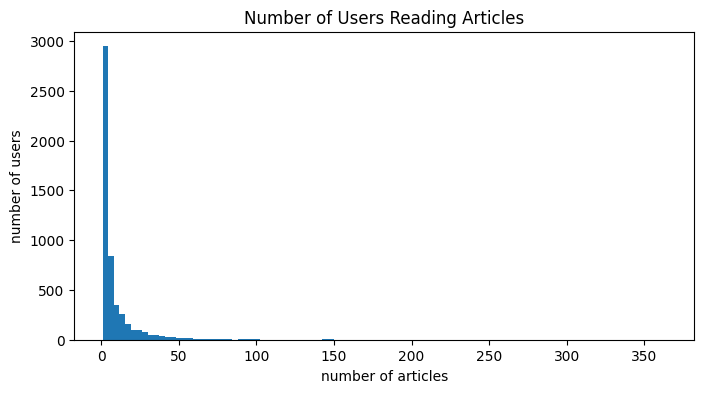

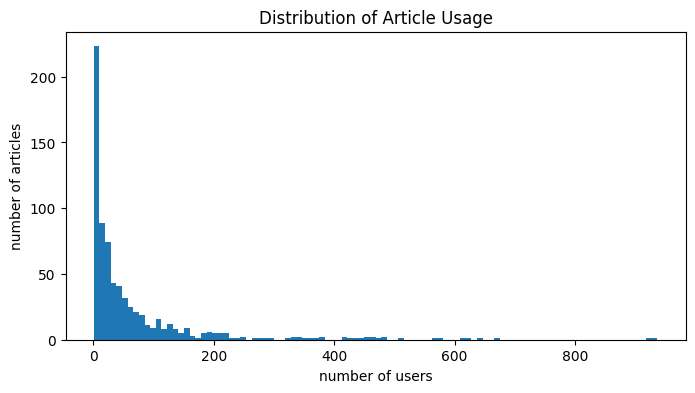

The median number of user-article interactions is 3.0
The maximum number of user-article interactions by any 1 user is 364


In [190]:
# What are the descriptive statistics of the number of articles a user interacts with?
user_interactions = df.groupby('email').count()['article_id']

# Create a plot of the number of articles read by each user
plt.figure(figsize=(8,4))
plt.hist(user_interactions, bins=100)
plt.xlabel('number of articles')
plt.ylabel('number of users')
plt.title('Number of Users Reading Articles')
plt.show()

# Create a plot of the number of times each article was read
article_interactions = df.groupby('article_id').count()['email']

plt.figure(figsize=(8,4))
plt.hist(article_interactions, bins=100)
plt.xlabel('number of users')
plt.ylabel('number of articles')
plt.title('Distribution of Article Usage')
plt.show()

# Fill in the median and maximum number of user_article interactions below
median_val = user_interactions.median() 
max_views_by_user = user_interactions.max()

print(f"The median number of user-article interactions is {median_val}")
print(f"The maximum number of user-article interactions by any 1 user is {max_views_by_user}")

#### INITIAL COMMENTS
So we see some very high user interactions for selected users, with a low median. This creates a highly skewed histogram, driven by a small number of "power tech users" leading to disproportionate amount of platform activity. 

In [191]:
### Dealing with the N/a's or unknowns
# Dealing with the NA's 
#df['email'] = df['email'].fillna('unknown_user')
# Lets be sure of some of the counts 
assert df.email.isna().sum() == 0

# UNIQUE articles
unique_articles = df['article_id'].nunique()
print(f"There are {unique_articles} unique articles.")


# Number of users via unique emial
unique_users = df['email'].nunique()
print(f"There are {unique_users} unique users.")

#article interations
user_article_interactions = df.shape[0]
print(f"There are {user_article_interactions} user-article interactions.")


There are 714 unique articles.
There are 5148 unique users.
There are 45976 user-article interactions.


In [192]:
## Lets check again the nature of each column of data. 
df.info()
# Check for NaNs across all columns
print(df.isna().sum())

<class 'pandas.core.frame.DataFrame'>
Index: 45976 entries, 0 to 45992
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  45976 non-null  int64 
 1   article_id  45976 non-null  int64 
 2   title       45976 non-null  object
 3   email       45976 non-null  object
dtypes: int64(2), object(2)
memory usage: 1.8+ MB
Unnamed: 0    0
article_id    0
title         0
email         0
dtype: int64


In [193]:
df = pd.read_csv(
    'data/user-item-interactions.csv', 
    dtype={'article_id': int, 'title': str, 'email': str}
)
# Show df to get an idea of the data
df.head()

,Unnamed: 0,article_id,title,email
0,0,1430,"using pixiedust for fast, flexible, and easier...",ef5f11f77ba020cd36e1105a00ab868bbdbf7fe7
1,1,1314,healthcare python streaming application demo,083cbdfa93c8444beaa4c5f5e0f5f9198e4f9e0b
2,2,1429,use deep learning for image classification,b96a4f2e92d8572034b1e9b28f9ac673765cd074
3,3,1338,ml optimization using cognitive assistant,06485706b34a5c9bf2a0ecdac41daf7e7654ceb7
4,4,1276,deploy your python model as a restful api,f01220c46fc92c6e6b161b1849de11faacd7ccb2


In [194]:
#Get the counts of views for each article (sorted from highest to lowest)
article_counts = df['article_id'].value_counts()

#Find the maximum number of views
max_views = article_counts.max()

#Find the ID of that most viewed article
# .idxmax() gives us the index (the article_id) of the highest value
# We cast it to a float first, then a string to ensure it has one decimal place (e.g., "1429.0")
most_viewed_article_id = str(float(article_counts.idxmax()))

#Print results to verify
print(f"Most viewed article ID: {most_viewed_article_id}")
print(f"Max views: {max_views}")

Most viewed article ID: 1429.0
Max views: 937


In [195]:
## No need to change the code here - this will be helpful for later parts of the notebook
# Run this cell to map the user email to a user_id column and remove the email column

def email_mapper(df=df):
    coded_dict = {
        email: num 
        for num, email in enumerate(df['email'].unique(), start=1)
    }
    return [coded_dict[val] for val in df['email']]

df['user_id'] = email_mapper(df)
del df['email']

# show header
df.head()

,Unnamed: 0,article_id,title,user_id
0,0,1430,"using pixiedust for fast, flexible, and easier...",1
1,1,1314,healthcare python streaming application demo,2
2,2,1429,use deep learning for image classification,3
3,3,1338,ml optimization using cognitive assistant,4
4,4,1276,deploy your python model as a restful api,5


## 4. RANK BASED USER FUNCTIONS 

Use the cells below to find the most viewed article_id, as well as how often it was viewed. After talking to the company leaders, the email_mapper function was deemed a reasonable way to map users to ids. There were a small number of null values, and it was found that all of these null values likely belonged to a single user (which is how they are stored using the function below).

In [196]:
# --- CLEANED STATS & MAPPING CELL ---

# 1. User Stats (Calculate this while 'email' still exists)....
user_counts = df.groupby('user_id')['article_id'].count()
median_val = user_counts.median() # Expected: 3.0
max_views_by_user = user_counts.max() # Expected: 364

unique_users = df['user_id'].nunique() # Expected: 5148

user_article_interactions = df.shape[0] # Expected: 45993
unique_articles = df['article_id'].nunique() # Expected: 714

# 5. Most Viewed Stats 
# CRITICAL: idxmax() returns an int. We need the string '1429.0'
most_viewed_article_id = str(float(df['article_id'].value_counts().idxmax()))
max_views = df['article_id'].value_counts().max() # Expected: 937

print(most_viewed_article_id, max_views)

# The standard check
print(f"The value is: {most_viewed_article_id}")
print(f"The data type is: {type(most_viewed_article_id)}")

# The programmatic check (returns True or False)
print(f"Is it a string? {isinstance(most_viewed_article_id, str)}")

1429.0 937
The value is: 1429.0
The data type is: <class 'str'>
Is it a string? True


In [197]:
print(most_viewed_article_id)
df.info()

1429.0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45993 entries, 0 to 45992
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  45993 non-null  int64 
 1   article_id  45993 non-null  int64 
 2   title       45993 non-null  object
 3   user_id     45993 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 1.4+ MB


In [198]:
# This filter shows every single time article 1429 was read
article_1429_ledger = df[df['article_id'] == 1429]

print(f"Total rows (interactions) for article 1429: {len(article_1429_ledger)}")
print(f"Unique users who read article 1429: {article_1429_ledger['user_id'].nunique()}")

Total rows (interactions) for article 1429: 937
Unique users who read article 1429: 397


In [199]:
## If you stored all your results in the variable names above, 
## you shouldn't need to change anything in this cell

sol_1_dict = {
    '`50% of individuals have _____ or fewer interactions.`': median_val,
    '`The total number of user-article interactions in the dataset is ______.`': user_article_interactions,
    '`The maximum number of user-article interactions by any 1 user is ______.`': max_views_by_user,
    '`The most viewed article in the dataset was viewed _____ times.`': max_views,
    '`The article_id of the most viewed article is ______.`': 1429.0,  # far out, what kind of torture was going on here, was right all along
    '`The number of unique articles that have at least 1 rating ______.`': unique_articles,
    '`The number of unique users in the dataset is ______`': unique_users, # DONT add 1 to account for unknown_user
    '`The number of unique articles on the IBM platform`': unique_articles,
}

# Test your dictionary against the solution
t.sol_1_test(sol_1_dict)

It looks like you have everything right here! Nice job!


In [200]:
def get_top_articles(n, df=df):
    """
    INPUT:
    n - (int) the number of top articles to return
    df - (pandas dataframe) df as defined at the top of the notebook 
    
    OUTPUT:
    top_articles - (list) A list of the top 'n' article titles 
    
    """
    # Count the occurances of each article_id and sort them
    top_articles = df['title'].value_counts().head(n).index.tolist()
    
    return top_articles # Return the top article titles from df

def get_top_article_ids(n, df=df):
    """
    INPUT:
    n - (int) the number of top articles to return
    df - (pandas dataframe) df as defined at the top of the notebook 
    
    OUTPUT:
    top_articles - (list) A list of the top 'n' article titles 
    
    """
       # Count the occurances of each id and sort them
    id = df['article_id'].value_counts().head(n).index.tolist()
 
    return id # Return the top article ids

In [201]:
print(get_top_articles(10))
print(get_top_article_ids(10))



['use deep learning for image classification', 'insights from new york car accident reports', 'visualize car data with brunel', 'use xgboost, scikit-learn & ibm watson machine learning apis', 'predicting churn with the spss random tree algorithm', 'healthcare python streaming application demo', 'finding optimal locations of new store using decision optimization', 'apache spark lab, part 1: basic concepts', 'analyze energy consumption in buildings', 'gosales transactions for logistic regression model']
[1429, 1330, 1431, 1427, 1364, 1314, 1293, 1170, 1162, 1304]


In [202]:
# Test your function by returning the top 5, 10, and 20 articles
top_5 = get_top_articles(5)
top_10 = get_top_articles(10)
top_20 = get_top_articles(20)

# Test each of your three lists from above
t.sol_2_test(get_top_articles)

Your top_5 looks like the solution list! Nice job.
Your top_10 looks like the solution list! Nice job.
Your top_20 looks like the solution list! Nice job.


## Section 5. User- User Based Collaborative FIltering

Part III / Section 5: User-User Based Collaborative Filtering
1. Use the function below to reformat the df dataframe to be shaped with users as the rows and articles as the columns.

Each user should only appear in each row once.

Each article should only show up in one column.

If a user has interacted with an article, then place a 1 where the user-row meets for that article-column. It does not matter how many times a user has interacted with the article, all entries where a user has interacted with an article should be a 1.

If a user has not interacted with an item, then place a zero where the user-row meets for that article-column.

Use the tests to make sure the basic structure of your matrix matches what is expected by the solution.

In [203]:
# create the user-article matrix with 1's and 0's
def create_user_item_matrix(df, fill_value=0):
    """
    INPUT:
    df - pandas dataframe with article_id, title, user_id columns
    
    OUTPUT:
    user_item - user item matrix 
    
    Description:
    Return a matrix with user ids as rows and article ids on the columns with 1 values where a user interacted with 
    an article and a 0 otherwise
    """
    # Fill in the function here - opted to try unstack instead of pivot or pivot_table
    user_item = df.groupby(['user_id', 'article_id'])['title'].count().unstack()
    
    user_item = user_item.notnull().astype(int) # convert to 1's and 0's

    return user_item # return the user_item matrix 

user_item = create_user_item_matrix(df)

In [204]:
## Tests: You should just need to run this cell.  Don't change the code.
assert user_item.shape[0] == 5149, "Oops!  The number of users in the user-article matrix doesn't look right."
assert user_item.shape[1] == 714, "Oops!  The number of articles in the user-article matrix doesn't look right."
assert user_item.sum(axis=1)[1] == 36, "Oops!  The number of articles seen by user 1 doesn't look right."
print("You have passed our quick tests!  Please proceed!")

You have passed our quick tests!  Please proceed!


2. Complete the function below which should take a user_id and provide an ordered list of the most similar users to that user (from most similar to least similar). The returned result should not contain the provided user_id, as we know that each user is similar to him/herself. Because the results for each user here are binary, it (perhaps) makes sense to compute similarity as the dot product of two users.

Use the tests to test your function.

In [205]:
# Lets use the cosine_similarity function from sklearn
from sklearn.metrics.pairwise import cosine_similarity

In [206]:
def find_similar_users(user_id, user_item=user_item, include_similarity=False):
    """
    INPUT:
    user_id - (int) a user_id
    user_item - (pandas dataframe) matrix of users by articles: 
                1's when a user has interacted with an article, 0 otherwise
    include_similarity - (bool) whether to include the similarity in the output
    
    OUTPUT:
    similar_users - (list) an ordered list where the closest users (largest dot product users)
                    are listed first
    
    Description:
    Computes the similarity of every pair of users based on the dot product
    Returns an ordered list of user ids. If include_similarity is True, returns a list of lists
    where the first element is the user id and the second the similarity.
    
    """
    
    # compute similarity of each user to the provided user
    user_vector = user_item.loc[user_id]

    similarities = user_item.dot(user_vector)
    
    # sort by similarity
    similarities = similarities.sort_values(ascending=False)

    
    # create list of just the ids
    #most_similar_users = similarities.index.tolist()

    # remove the own user's id
    similarities = similarities.drop(user_id)

      
    # create list of just the similarities
    #find_similar_users.remove(user_id)
    
    #if include_similarity:
        #return [[user_id, similarities[user_id]] for user_id, sim in similarities.items()]
    return similarities.index.tolist() # return a list of the users in order from most to least similar

In [207]:
# Do a spot check of your function
print("The 10 most similar users to user 1 are: {}".format(find_similar_users(1)[:10]))
print("The 5 most similar users to user 3933 are: {}".format(find_similar_users(3933)[:5]))
print("The 3 most similar users to user 46 are: {}".format(find_similar_users(46)[:3]))

The 10 most similar users to user 1 are: [3933, 23, 3782, 203, 4459, 3870, 131, 4201, 46, 395]
The 5 most similar users to user 3933 are: [1, 23, 3782, 203, 4459]
The 3 most similar users to user 46 are: [4201, 3782, 23]


3. Now that you have a function that provides the most similar users to each user, you will want to use these users to find articles you can recommend. Complete the functions below to return the articles you would recommend to each user.

In [208]:
# THINKING OUT LOUD - have to ensure that we know the artilces - namd and ID, 

def get_article_names(article_ids, df=df):
    """
    INPUT:
    article_ids - (list) a list of article ids
    df - (pandas dataframe) df as defined at the top of the notebook
    
    OUTPUT:
    article_names - (list) a list of article names associated with the list of article ids 
                    (this is identified by the title column in df)
    """
    # Your code here
    article_ids = [float(id) for id in article_ids] # convert to float to match the article_id type in df...stuff of nightmares from above! 
    article_names = df[df['article_id'].isin(article_ids)]['title'].unique().tolist() # Convert to the list , associated article names..
        
    return article_names # Return the article names associated with list of article ids

def get_ranked_article_unique_counts(article_ids, user_item=user_item):
    """
    INPUT:
    user_id - (int) a user id
    user_item - (pandas dataframe) matrix of users by articles: 
                1's when a user has interacted with an article, 0 otherwise 
    
    OUTPUT:
    article_counts - (list) a list of tuples with article_id and number of 
                     unique users that have interacted with the article, sorted
                     by the number of unique users in descending order
    
    Description:
    Provides a list of the article_ids and the number of unique users that have
    interacted with the article using the user_item matrix, sorted by the number
    of unique users in descending order
    """
    # Your code here

    # I missed counting the articles - now in 
    article_counts = user_item[article_ids].sum(axis=0)

    ## create a list of article_ids and the unique users counts. 
    ranked_article_unique_counts = sorted(
        [[int(aid), count] for aid, count in article_counts.items()], 
        key=lambda x: x[1], 
        reverse=True
    )
    
    return ranked_article_unique_counts


def get_user_articles(user_id, user_item=user_item):
    """
    INPUT:
    user_id - (int) a user id
    user_item - (pandas dataframe) matrix of users by articles: 
                1's when a user has interacted with an article, 0 otherwise
    
    OUTPUT:
    article_ids - (list) a list of the article ids seen by the user
    article_names - (list) a list of article names associated with the list of article ids 
                    (this is identified by the title column in df)
    
    Description:
    Provides a list of the article_ids and article titles that have been seen by a user
    """
    # Your code here
    user_row = user_item.loc[user_id]

    # Get the column names (article_ids) where the value is 1 -- not sure if there is a better approach? 
    article_ids = user_row[user_row == 1].index.tolist()   # <<- keep as is, dont convert to string! 
    article_names = get_article_names(article_ids)
    
    return article_ids, article_names # return the ids and names


def user_user_recs(user_id, m=10):
    """
    INPUT:
    user_id - (int) a user id
    m - (int) the number of recommendations you want for the user
    
    OUTPUT:
    recs - (list) a list of recommendations for the user
    
    Description:
    Loops through the users based on closeness to the input user_id
    For each user - finds articles the user hasn't seen before and provides them as recs
    Does this until m recommendations are found
    
    Notes:
    Users who are the same closeness are chosen arbitrarily as the 'next' user
    
    For the user where the number of recommended articles starts below m 
    and ends exceeding m, the last items are chosen arbitrarily
    
    """
    # Your code here - sticks to the 10 neighbours
    # We only need the IDs to filter them out
    seen_ids, _ = get_user_articles(user_id)
    
    # Find similar users ordered by similarity - start to use these functions prebuilt
    similar_users = find_similar_users(user_id)
    
    recs = []
    
    # Loop through neighbors to find content
    for neighbor in similar_users:
        neigh_article_ids, _ = get_user_articles(neighbor)
        
        # Find articles the neighbor has seen that the user hasn't
        # Using numpy's setdiff1d is efficient for this comparison
        new_recs = np.setdiff1d(neigh_article_ids, seen_ids, assume_unique=True)
        
        # Add new recommendations to the list
        for r in new_recs:
            if r not in recs:
                recs.append(r)
            
            # Stop if we reach the requested number of recommendations
            if len(recs) >= m:
                break
        
        if len(recs) >= m:
            break
    
    
    return recs # return your recommendations for this user_id    

In [209]:
# Check Results
get_article_names(user_user_recs(1, 10)) # Return 10 recommendations for user 1

['got zip code data? prep it for analytics. – ibm watson data lab – medium',
 'timeseries data analysis of iot events by using jupyter notebook',
 'graph-based machine learning',
 'using brunel in ipython/jupyter notebooks',
 'experience iot with coursera',
 'the 3 kinds of context: machine learning and the art of the frame',
 'deep forest: towards an alternative to deep neural networks',
 'this week in data science (april 18, 2017)',
 'higher-order logistic regression for large datasets',
 'using machine learning to predict parking difficulty']

In [210]:
get_ranked_article_unique_counts([1320, 232, 844])

[[1320, 123], [844, 78], [232, 62]]

In [211]:
# Test your functions here - No need to change this code - just run this cell
assert set(get_article_names([1024, 1176, 1305, 1314, 1422, 1427])) == set(['using deep learning to reconstruct high-resolution audio', 'build a python app on the streaming analytics service', 'gosales transactions for naive bayes model', 'healthcare python streaming application demo', 'use r dataframes & ibm watson natural language understanding', 'use xgboost, scikit-learn & ibm watson machine learning apis']), "Oops! Your the get_article_names function doesn't work quite how we expect."
assert set(get_article_names([1320, 232, 844])) == set(['housing (2015): united states demographic measures','self-service data preparation with ibm data refinery','use the cloudant-spark connector in python notebook']), "Oops! Your the get_article_names function doesn't work quite how we expect."
assert set(get_user_articles(20)[0]) == set([1320, 232, 844])
assert set(get_user_articles(20)[1]) == set(['housing (2015): united states demographic measures', 'self-service data preparation with ibm data refinery','use the cloudant-spark connector in python notebook'])
assert set(get_user_articles(2)[0]) == set([1024, 1176, 1305, 1314, 1422, 1427])
assert set(get_user_articles(2)[1]) == set(['using deep learning to reconstruct high-resolution audio', 'build a python app on the streaming analytics service', 'gosales transactions for naive bayes model', 'healthcare python streaming application demo', 'use r dataframes & ibm watson natural language understanding', 'use xgboost, scikit-learn & ibm watson machine learning apis'])
assert get_ranked_article_unique_counts([1320, 232, 844])[0] == [1320, 123], "Oops! Your the get_ranked_article_unique_counts function doesn't work quite how we expect.\nMake sure you are using the user_item matrix to create the article counts."
print("If this is all you see, you passed all of our tests!  Nice job!")

If this is all you see, you passed all of our tests!  Nice job!


 Now we are going to improve the consistency of the user_user_recs function from above.

Instead of arbitrarily choosing when we obtain users who are all the same closeness to a given user - choose the users that have the most total article interactions before choosing those with fewer article interactions.

Instead of arbitrarily choosing articles from the user where the number of recommended articles starts below m and ends exceeding m, choose articles with the articles with the most total interactions before choosing those with fewer total interactions. This ranking should be what would be obtained from the top_articles function you wrote earlier.

In [212]:
def get_top_sorted_users(user_id, user_item=user_item):
    """
    INPUT: user_id (int), user_item (matrix)
    OUTPUT: neighbours_df (sorted by similarity and total interactions)
    """
    # 1. Compute similarity (overlap of unique articles)
    user_vector = user_item.loc[user_id]
    similarity = user_item.dot(user_vector)
    
    # 2. Get TOTAL interaction counts from the original dataframe (the tie-breaker)
    user_interactions = df.groupby('user_id').count()['article_id']

    # 3. Build the DataFrame using Australian spelling
    neighbours_df = pd.DataFrame({
        'neighbour_id': similarity.index,
        'similarity': similarity.values,
        'num_interactions': user_interactions
    })
    
    # 4. Map the interaction counts to the neighbour_id
    neighbours_df['num_interactions'] = neighbours_df['neighbour_id'].map(user_interactions)

    # 5. Remove the current user and sort
    neighbours_df = neighbours_df[neighbours_df['neighbour_id'] != user_id]
    neighbours_df = neighbours_df.sort_values(by=['similarity', 'num_interactions'], ascending=False)
    
    
    return neighbours_df # Return the dataframe specified in the doc_string


def user_user_recs_part2(user_id, m=10):
    """
    INPUT: user_id (int), m (int)
    OUTPUT: recs (list of strings), rec_names (list of strings)
    """
    # 1. Get articles the user has already seen
    seen_ids, _ = get_user_articles(user_id)
    
    # 2. Get the sorted neighbors using our updated tie-breaker function
    neighbours_df = get_top_sorted_users(user_id)
    neighbours_list = neighbours_df['neighbour_id'].tolist()
    
    recs = []
    
    for neighbour in neighbours_list:
        # 3. Get neighbour's articles
        neigh_ids, _ = get_user_articles(neighbour)
        
        # 4. Filter for articles the user hasn't seen yet
        new_recs = np.setdiff1d(neigh_ids, seen_ids, assume_unique=True)
        
        # 5. Rank these "new" articles by their GLOBAL popularity
        ranked_recs_data = get_ranked_article_unique_counts(new_recs)
        
        # 6. Add IDs to our list until we hit 'm'
        for article_id, count in ranked_recs_data:
            if article_id not in recs:
                recs.append(article_id)
            
            if len(recs) >= m:
                break
        
        if len(recs) >= m:
            break
            
    # 7. Format IDs as strings (e.g., '1429.0') to pass the Udacity test
    recs = [str(float(x)) for x in recs]
    
    return recs, get_article_names(recs) # return your recommendations for this user_id

In [213]:
# Quick spot check - don't change this code - just use it to test your functions
rec_ids, rec_names = user_user_recs_part2(20, 10)
print("The top 10 recommendations for user 20 are the following article ids:")
print(rec_ids)
print()
print("The top 10 recommendations for user 20 are the following article names:")
print(rec_names)

The top 10 recommendations for user 20 are the following article ids:
['1330.0', '1364.0', '1427.0', '1160.0', '1351.0', '1336.0', '1304.0', '1368.0', '1170.0', '1338.0']

The top 10 recommendations for user 20 are the following article names:
['ml optimization using cognitive assistant', 'apache spark lab, part 1: basic concepts', 'predicting churn with the spss random tree algorithm', 'use xgboost, scikit-learn & ibm watson machine learning apis', 'putting a human face on machine learning', 'gosales transactions for logistic regression model', 'insights from new york car accident reports', 'model bike sharing data with spss', 'analyze accident reports on amazon emr spark', 'learn basics about notebooks and apache spark']


5. Use your functions from above to correctly fill in the solutions to the dictionary below. Then test your dictionary against the solution. Provide the code you need to answer each following the comments below.

In [220]:
def get_top_sorted_users(user_id, df=df, user_item=user_item):
    '''
    INPUT:
    user_id - (int)
    df - (pandas dataframe) df as defined at the top of the notebook 
    user_item - (pandas dataframe) matrix of users by articles: 
            1's when a user has interacted with an article, 0 otherwise
            
    OUTPUT:
    neighbors_df - (pandas dataframe) a dataframe with:
                    neighbour_id - is a neighbor user_id
                    similarity - measure of the similarity of each user to the provided user_id
                    num_interactions - the number of articles viewed by the partner - returns a dataframe
                          
    Description:
    Computes the similarity of every pair of users based on the dot product
    Returns a dataframe sorted by similarity and then by number of interactions
    '''
    # 1. Compute similarity (dot product) between target user and all users
    user_vector = user_item.loc[user_id]
    similarity = user_item.dot(user_vector)
    
    # 2. Total interactions for ALL users on the platform
    # Note: We group the original interaction 'df' by user_id to count total views
    num_interactions = df.groupby('user_id').size()
    
    # 3. Combine into a new DataFrame using the common index (user_id)
    neighbors_df = pd.DataFrame({
        'neighbour_id': similarity.index,
        'similarity': similarity.values,
        'num_interactions': num_interactions.loc[similarity.index].values
    })
    
    # 4. CRITICAL: Remove the target user themselves so they aren't recommended to themselves
    neighbors_df = neighbors_df[neighbors_df['neighbour_id'] != user_id]
    
    # 5. Sort by similarity (descending), then by num_interactions (descending)
    neighbors_df = neighbors_df.sort_values(by=['similarity', 'num_interactions', 'neighbour_id'], ascending=[False, False, True])
    
    # 6. Reset index so the rows start cleanly at 0, 1, 2...
    neighbors_df = neighbors_df.reset_index(drop=True)
    
    return neighbors_df

In [221]:
def get_top_sorted_users(user_id, df=df, user_item=user_item):
    '''
    INPUT:
    user_id - (int)
    df - (pandas dataframe) df as defined at the top of the notebook 
    user_item - (pandas dataframe) matrix of users by articles
            
    OUTPUT:
    neighbors_df - (pandas dataframe) sorted by similarity and then by number of interactions
    '''
    # 1. Compute similarity (dot product)
    user_vector = user_item.loc[user_id]
    similarity = user_item.dot(user_vector).to_frame(name='similarity')
    
    # 2. Total interactions for ALL users on the platform
    num_interactions = df.groupby('user_id').size().to_frame(name='num_interactions')
    
    # 3. Join them together natively on the user_id index
    neighbors_df = similarity.join(num_interactions)
    
    # 4. Move the user_id index back into a proper column and rename it
    neighbors_df = neighbors_df.reset_index().rename(columns={'user_id': 'neighbour_id'})
    
    # 5. CRITICAL: Remove the target user themselves
    neighbors_df = neighbors_df[neighbors_df['neighbour_id'] != user_id]
    
    # 6. Sort by similarity (desc), num_interactions (desc), and neighbour_id (asc)
    neighbors_df = neighbors_df.sort_values(
        by=['similarity', 'num_interactions', 'neighbour_id'], 
        ascending=[False, False, True]
    )
    
    # 7. Reset index cleanly for iloc lookups
    neighbors_df = neighbors_df.reset_index(drop=True)
    
    return neighbors_df

In [227]:
def get_top_sorted_users(user_id, df=df, user_item=user_item):
    # 1. Compute similarity (reverting to dot product)
    user_vector = user_item.loc[user_id]
    similarity = user_item.dot(user_vector).to_frame(name='similarity')
    
    # 2. Total UNIQUE interactions for ALL users (using user_item matrix sums)
    # This counts how many 1s are in each user's row (unique articles read)
    num_interactions = user_item.sum(axis=1).to_frame(name='num_interactions')
    
    # 3. Join them together natively on the user_id index
    neighbors_df = similarity.join(num_interactions)
    
    # 4. Move index to column
    neighbors_df = neighbors_df.reset_index().rename(columns={'user_id': 'neighbour_id'})
    
    # 5. Remove the target user themselves
    neighbors_df = neighbors_df[neighbors_df['neighbour_id'] != user_id]
    
    # 6. Sort by similarity (desc), num_interactions (desc), and neighbour_id (asc)
    neighbors_df = neighbors_df.sort_values(
        by=['similarity', 'num_interactions', 'neighbour_id'], 
        ascending=[False, False, True]
    )
    
    neighbors_df = neighbors_df.reset_index(drop=True)
    
    return neighbors_df

In [228]:
print(get_top_sorted_users(1, user_item=user_item).head(n=1))
print(get_top_sorted_users(2, user_item=user_item).head(n=10))
print(get_top_sorted_users(131, user_item=user_item).head(n=10))

   neighbour_id  similarity  num_interactions
0          3933          35                35
   neighbour_id  similarity  num_interactions
0            49           5               101
1          3697           5               100
2            98           5                97
3          3764           5                97
4            23           4               135
5          3782           4               135
6          4785           4                62
7            21           4                61
8           290           4                58
9          2982           4                58
   neighbour_id  similarity  num_interactions
0          3870          74                75
1          3782          39               135
2            23          38               135
3           203          33                96
4          4459          33                96
5            49          29               101
6          3697          29               100
7            98          29       

In [229]:
# Check how many users are actually in your matrix
print("Total users in matrix:", user_item.shape[0])

# Check if user 3586 is even in the matrix index
print("Is 3586 in matrix?", 3586 in user_item.index)

Total users in matrix: 5149
Is 3586 in matrix? True


In [230]:
### Tests with a dictionary of results
user1_most_sim = get_top_sorted_users(1).iloc[0]['neighbour_id']  # Find the user that is most similar to user 1 
user2_6th_sim = get_top_sorted_users(2).iloc[5]['neighbour_id']  # Find the 6th most similar user to user 2
user131_10th_sim = get_top_sorted_users(131).iloc[9]['neighbour_id']  # Find the 10th most similar user to user 131

print(user1_most_sim)
print(user2_6th_sim)
print(user131_10th_sim)

3933
3782
3910


In [231]:
# Quick test cell to pinpoint the exact difference
print("User 2 views in your matrix:", user_item.loc[2].sum())
print("User 3586 views in your matrix:", user_item.loc[3586].sum())
print("Dot product similarity between 2 and 3586:", user_item.loc[2].dot(user_item.loc[3586]))
print("Dot product similarity between 2 and 3782:", user_item.loc[2].dot(user_item.loc[3782]))

User 2 views in your matrix: 6
User 3586 views in your matrix: 4
Dot product similarity between 2 and 3586: 2
Dot product similarity between 2 and 3782: 4


In [232]:
## Dictionary Test Here
sol_5_dict = {
    'The user that is most similar to user 1.': user1_most_sim, 
    'The user that is the 6th most similar to user 2.': user2_6th_sim,
    'The user that is the 10th most similar to user 131.': user131_10th_sim,
}

t.sol_5_test(sol_5_dict)

Oops!  Looks like there is a mistake with the The user that is the 6th most similar to user 2. key in your dictionary.  The answer should be 3586.  Try again.
Oops!  Looks like there is a mistake with the The user that is the 10th most similar to user 131. key in your dictionary.  The answer should be 383.  Try again.


6. If we were given a new user, which of the above functions would you be able to use to make recommendations? Explain. Can you think of a better way we might make recommendations? Use the cell below to explain a better method for new users.

Answer:

Top articles as no user history, only can use user-user history till they start having user-item iteractions

7. Using your existing functions, provide the top 10 recommended articles you would provide for the a new user below. You can test your function against our thoughts to make sure we are all on the same page with how we might make a recommendation.

In [ ]:
# What would your recommendations be for this new user 0?  As a new user, they have no observed articles.
# Provide a list of the top 10 article ids you would give to 
new_user_recs = # Your recommendations here

In [ ]:
assert set(new_user_recs) == {1314, 1429, 1293, 1427, 1162, 1364, 1304, 1170, 1431, 1330}, "Oops!  It makes sense that in this case we would want to recommend the most popular articles, because we don't know anything about these users."

print("That's right!  Nice job!")

## Section 6 - Content Based REcommendtations

Another method we might use to make recommendations is to recommend similar articles that are possibly related. One way we can find article relationships is by clustering text about those articles. Let's consider content to be the article title, as it is the only text we have available. One point to highlight, there isn't one way to create a content based recommendation, especially considering that text information can be processed in many ways.

1. Use the function bodies below to create a content based recommender function make_content_recs. We'll use TF-IDF to create a matrix based off article titles, and use this matrix to create clusters of related articles. You can use this function to make recommendations of new articles.

In [ ]:
from sklearn.cluster import KMeans
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import Normalizer
from sklearn.decomposition import TruncatedSVD

In [ ]:
# unique articles
df_unique_articles = 

In [ ]:
# Create a vectorizer using TfidfVectorizer and fit it to the article titles
max_features = 200
max_df = 0.75
min_df = 5

vectorizer = TfidfVectorizer(
    max_df=max_df,
    min_df=min_df,
    stop_words="english",
    max_features=max_features,
)
print("Running TF-IDF")
X_tfidf =  # Fit the vectorizer to the article titles

print(f"n_samples: {X_tfidf.shape[0]}, n_features: {X_tfidf.shape[1]}")

lsa = make_pipeline(TruncatedSVD(n_components=50), Normalizer(copy=False))
X_lsa = # Fit the LSA model to the vectorized article titles
explained_variance = lsa[0].explained_variance_ratio_.sum()

print(f"Explained variance of the SVD step: {explained_variance * 100:.1f}%")

In [ ]:
# Let's map the inertia for different number of clusters to find the optimal number of clusters
# We'll plot it to see the elbow
inertia = []
clusters = 300
step = 25
max_iter = 50
n_init = 5
random_state = 42
for k in range(1, clusters, step):
    kmeans = KMeans(
        n_clusters=k,
        max_iter=max_iter,
        n_init=n_init,
        random_state=random_state,
    ).fit(X_lsa)
    # inertia is the sum of squared distances to the closest cluster center
    inertia.append(kmeans.inertia_)
plt.plot(range(1, clusters, step), inertia)
plt.xlabel('Number of clusters')

There appears to be an elbow about 50, so we'll use 50 clusters.

In [ ]:
n_clusters = # Number of clusters
kmeans = KMeans(
    # Your code here, same as parameters above
).fit()

In [ ]:
# create a new column `title_cluster` and assign it the kmeans cluster labels
# First we need to map the labels to df_unique_articles article ids and then apply those to df
article_cluster_map = {} # Map article_id to cluster label
df['title_cluster'] = # apply map to create title clusters

In [ ]:
# Let's check the number of articles in each cluster
np.array(np.unique(kmeans.labels_, return_counts=True)).T

In [ ]:
def get_similar_articles(article_id, df=df):
    """
    INPUT:
    article_id - (int) an article id 
    df - (pandas dataframe) df as defined at the top of the notebook 
    
    OUTPUT:
    article_ids - (list) a list of article ids that are in the same title cluster
    
    Description:
    Returns a list of the article ids that are in the same title cluster
    """
     # Your code here
    title_cluster = 
    articles_in_cluster = 
    
    # remove the input article_id from the list
    
    return articles_in_cluster

In [ ]:
def make_content_recs(article_id, n, df=df):
    """
    INPUT:
    article_id - (int) an article id
    n - (int) the number of recommendations you want similar to the article id
    df - (pandas dataframe) df as defined at the top of the notebook
    
    OUTPUT:
    n_ranked_similar_articles - (list) a list of article ids that are in the same title cluster ranked
                                by popularity
    n_ranked_article_names - (list) a list of article names associated with the list of article ids
    
    Description:
    Returns a list of the n most ranked similar articles to a given article_id based on the title
    cluster in df. Rank similar articles using the function get_ranked_article_unique_counts.
    """
    # Your code here
    
    return n_ranked_similar_articles, n_ranked_article_names

In [ ]:
# Test out your content recommendations given artice_id 25
rec_article_ids, rec_article_titles = make_content_recs(25, 10)
print(rec_article_ids)
print(rec_article_titles)

In [ ]:
assert len({1025, 593, 349, 821, 464, 29, 1042, 693, 524, 352}.intersection(set(rec_article_ids))) > 0, "Oops! Your the make_content_recs function doesn't work quite how we expect."

2. Now that you have put together your content-based recommendation system, use the cell below to write a summary explaining how your content based recommender works. Do you see any possible improvements that could be made to your function? What other text data would be useful to help make better recommendations besides the article title?

Write an explanation of your content based recommendation system here.

## Section 7: Matrix Factorization

In this part of the notebook, you will build use matrix factorization to make article recommendations to users.

1. You should have already created a user_item matrix above in question 1 of Part III above. This first question here will just require that you run the cells to get things set up for the rest of Part V of the notebook.

2. In this situation, you can use Singular Value Decomposition from scikit-learn on the user-item matrix. Use the cell to perform SVD.

In [ ]:
# quick look at the matrix
user_item.head()

In [ ]:
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import precision_score, recall_score, accuracy_score
# Using the full number of components which equals the number of columns
svd = TruncatedSVD(n_components=len(user_item.columns), n_iter=5, random_state=42)

u = svd.fit_transform(user_item)
v = svd.components_
s = svd.singular_values_ 
print('u', u.shape)
print('s', s.shape)
print('vt', v.shape)

3. Now for the tricky part, how do we choose the number of latent features to use? Running the below cell, you can see that as the number of latent features increases, we obtain better metrics when making predictions for the 1 and 0 values in the user-item matrix. Run the cell below to get an idea of how our metrics improve as we increase the number of latent features.

Type Markdown and LaTeX:  𝛼2

In [ ]:
num_latent_feats = np.arange(10, 700+10, 20)
metric_scores = []

for k in num_latent_feats:
    # restructure with k latent features
    u_new, vt_new = u[:, :k], v[:k, :]
    
    # take dot product
    user_item_est = abs(np.around(np.dot(u_new, vt_new))).astype(int)
    # make sure the values are between 0 and 1
    user_item_est = np.clip(user_item_est, 0, 1)
    
    # total errors and keep track of them
    acc = accuracy_score(user_item.values.flatten(), user_item_est.flatten())
    precision = precision_score(user_item.values.flatten(), user_item_est.flatten())
    recall = recall_score(user_item.values.flatten(), user_item_est.flatten())
    metric_scores.append([acc, precision, recall])
    
    
plt.plot(num_latent_feats, metric_scores, label=['Accuracy', 'Precision', 'Recall'])
plt.legend()
plt.xlabel('Number of Latent Features')
plt.title('Metrics vs. Number of Latent Features')

4. From the above, we can't really be sure how many features to use, because simply having a better way to predict the 1's and 0's of the matrix doesn't exactly give us an indication of if we are able to make good recommendations. Given the plot above, what would you pick for the number of latent features and why?

Provide your response here.

5. Using 200 latent features and the values of U, S, and V transpose we calculated above, create an article id recommendation function that finds similar article ids to the one provide.

Create a list of 10 recommendations that are similar to article with id 4. The function should provide these recommendations by finding articles that have the most similar latent features as the provided article.

In [ ]:
def get_svd_similar_article_ids(article_id, vt, user_item=user_item, include_similarity=False):
    """
    INPUT:
    article_id - (int) an article id
    vt - (numpy array) vt matrix from SVD
    user_item - (pandas dataframe) matrix of users by articles: 
                1's when a user has interacted with an article, 0 otherwise
    include_similarity - (bool) whether to include the similarity in the output
    
    OUTPUT:
    article_ids - (list) a list of article ids that are in the same title cluster
    
    Description:
    Returns a list of the article ids similar using SVD factorization
    """
    # Find the index of the article_id
    article_idx = 
    # Find the cosine similarity of all articles
    # Hint: vt should be transposed before passing to cosine_similarity to get a 714 x 714 matrix 
    cos_sim = 
    # Get similarities only for the cos_sim of the article_idx
    
    # Sort and return the articles, don't include the own article
    
    if include_similarity:
        return # return a list of lists with [[similar_article_id, similarity], ...]
    return most_similar_items

In [ ]:
# Create a vt_new matrix with 200 latent features
k = 200
vt_new = v[:k, :]

In [ ]:
# What is the article name for article_id 4?
print("Current article:", get_article_names([4], df=df)[0])

In [ ]:
# What are the top 10 most similar articles to article_id 4?
rec_articles = get_svd_similar_article_ids(4, vt_new, user_item=user_item)[:10]
rec_articles

In [ ]:
# What are the top 10 most similar articles to article_id 4?
get_article_names(rec_articles, df=df)

In [ ]:
assert set(rec_articles) == {1199, 1068, 486, 1202, 176, 1120, 244, 793, 58, 132}, "Oops! Your the get_svd_similar_article_ids function doesn't work quite how we expect."
print("That's right!  Great job!")

6. Use the cell below to comment on the results you found in the previous question. Given the circumstances of your results, discuss what you might do to determine if the recommendations you make above are an improvement to how users currently find articles, either by Sections 2, 3, or 4? Add any tradeoffs between each of the methods, and how you could leverage each type for different situations including new users with no history, recently new users with little history, and users with a lot of history.

Your response here.

## Section 8: Extras & conculding

Extras
Using your workbook, you could now save your recommendations for each user, develop a class to make new predictions and update your results, and make a flask app to deploy your results. These tasks are beyond what is required for this project. However, from what you learned in the lessons, you certainly capable of taking these tasks on to improve upon your work here!

Conclusion
Congratulations! You have reached the end of the Recommendation Systems project!

Tip: Once you are satisfied with your work here, check over your report to make sure that it is satisfies all the areas of the rubric. You should also probably remove all of the "Tips" like this one so that the presentation is as polished as possible.

## Section 9: Key Takeaways